In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Self
from dataclasses import dataclass
from typing import Dict, List, Tuple, Iterable

import math


Land:
    0.5 Wealth, 2.0 Food
    Each pop can work 1 unit of land
    
    Land Ownership
        Commoner Owned
        Elite Owned

    Commoners can work land.
    Elites can hire commoners at some wage rate, W.
        Wages will increase if demand (amount of elite land to be cultivated profitably at rate W, E_W) > supply (amount of commoners willing to work at rate W, C_W)

    E_W is determined by:
        Food prices
        How much each land type can produce
    
    Any land not worked will not produce.

Population:
    Commoners
    Elites

    Each class, with plentiful food, will have population growth.
    Each population unit requires a certain amount of food to not starve.
        Pops will not work for money if that money cannot buy them food



Resources:
    Wealth - start
        req = 2^0.4x - 1
    Food - start
        req = 1
    Consumables
        Produced by Urbanites
        req = 0.02*max(0,x-5)*2^0.4x
    Luxuries
        req = max(0,x-10)^2



In [2]:
ResourceId = int

In [3]:
@dataclass(frozen=True, slots=True)
class Resource:
    id: ResourceId
    slug: str                   # canonical key
    heaviness: float = 1.0      # drives transport cost
    start_price: float = 1.0    # starting long-run price

class ResourceRegistry:
    def __init__(self):
        self._by_slug: Dict[str, Resource] = {}
        self._by_id: List[Resource] = []

    def add(self, slug: str, **kw) -> Resource:
        slug = slug.strip().lower()
        if slug in self._by_slug:
            raise ValueError(f"Duplicate resource slug '{slug}'")
        r = Resource(id=len(self._by_id), slug=slug, **kw)
        self._by_slug[slug] = r
        self._by_id.append(r)
        return r

    def get(self, key: str | int) -> Resource:
        if isinstance(key, int):
            return self._by_id[key]
        return self._by_slug[key.strip().lower()]

    def all(self) -> Iterable[Resource]:
        return tuple(self._by_id)

In [4]:
@dataclass(frozen=True, slots=True)
class Recipe:
    name: str
    # list of (resource_id, qty) per 1 "labor unit" or 1 "cycle"
    inputs:  Tuple[Tuple[ResourceId, float], ...]
    outputs: Tuple[Tuple[ResourceId, float], ...]
    # optional tags for later (tools boost, skill type, etc.)
    tags:    Tuple[str, ...] = ()

In [5]:
class Market:
    def __init__(
            self, 
            registry: ResourceRegistry,
            sigma: float = 2.0,                 # how much gluts/shortages impact prices
            beta: float = 0.05,                 # how fast base moves towards short
            price_floor: float = 0.25,          # min short price (abs)
            price_ceiling: float = 10_000,      # max short price (abs)
            price_factor: float = 4.0,          # max short price factor relative to base price (rel)
            pseudovolume: float = 1.0,          # Lambda, adds to both S & D
            volume_half: float = 10.0,          # activity scale for base drift
            one_side_scale=0.3,                 # slowdown if only S or D present
            base_move_factor=1.2,               # base can only move by this factor towards the short
            anchor_slug: str | int = "Gold",    # Anchor good to keep prices stable (normally gold)
            anchor_influence: float = 0.2,      # How much the anchor influences other prices
            epsilon=1e-9
        ):
        self.R = registry
        self.sigma = sigma
        self.beta = beta
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.price_factor = price_factor
        self.pseudovolume = pseudovolume
        self.volume_half = volume_half
        self.one_side_scale = one_side_scale
        self.base_move_factor = base_move_factor
        self.epsilon = epsilon
        
        ANCHOR = self.R.get(anchor_slug)
        self.anchor_id = ANCHOR.id
        self.anchor_target = ANCHOR.start_price
        self.anchor_influence = anchor_influence

        # storage keyed by resource id
        self.base_price: Dict[int, float]  = {}
        self.short_price: Dict[int, float] = {}
        self.supply: Dict[int, float]      = {}
        self.demand: Dict[int, float]      = {}

        # initialize from registry defaults
        for r in self.R.all():
            self.base_price[r.id]  = r.start_price
            self.short_price[r.id] = r.start_price
            self.supply[r.id] = 0.0
            self.demand[r.id] = 0.0

    # ---- Helpers keyed by slug or id ----
    def _rid(self, key: str | int) -> int:
        return self.R.get(key).id

    def set_supply(self, key: str | int, qty: float) -> None:
        self.supply[self._rid(key)] = float(qty)

    def add_supply(self, key: str | int, qty: float) -> None:
        rid = self._rid(key); self.supply[rid] += float(qty)

    def set_demand(self, key: str | int, qty: float) -> None:
        self.demand[self._rid(key)] = float(qty)

    def add_demand(self, key: str | int, qty: float) -> None:
        rid = self._rid(key); self.demand[rid] += float(qty)

    def get_short(self, key: str | int) -> float:
        return self.short_price[self._rid(key)]

    def get_base(self, key: str | int) -> float:
        return self.base_price[self._rid(key)]
    

    # ---- Pricing rules ----
    def compute_short_prices(self) -> None:
        """Recompute short-run prices from current S/D and base prices."""
        fctr  = self.price_factor

        for r in self.R.all():
            rid = r.id
            s = max(self.supply[rid], self.epsilon)
            d = max(self.demand[rid], self.epsilon)

            ratio = (d / s) ** self.sigma
            if ratio > fctr: ratio = fctr
            elif ratio < 1/fctr: ratio = 1/fctr

            p = self.base_price[rid] * ratio
            
            # guardrails
            if p < self.price_floor: p = self.price_floor
            elif p > self.price_ceiling: p = self.price_ceiling

            self.short_price[rid] = p

    def nudge_base_prices(self) -> None:
        """
        Slowly move base price toward short but...
        - slower at low activity
        - slower if only one side present
        - relatively capped

        Anchor stays fixed, but it causes other base prices to drift instead
        """

        # Compute Anchor "price level error"
        # p_err < 1.0 = more demand than there should = too much money = reduce prices
        # p_err > 1.0 = more supply than there should = too little money = increase prices 
        aid = self.anchor_id
        self.base_price[aid] = self.anchor_target
        Sa, Da = self.supply[aid], self.demand[aid]

        anchor_dif = (self.anchor_target - self.short_price[aid]) / self.anchor_target
        if not (Sa > 0.0 and Da > 0.0):
            anchor_dif *= self.one_side_scale

        a_activity = min(Sa, Da)
        anchor_dif *= a_activity / (a_activity + self.volume_half)
        
        p_err = min(max((self.anchor_influence * anchor_dif) + 1.0, 1.0/self.base_move_factor), self.base_move_factor)

        # Good = Base | Short
        # Gold = 100 | 120
        # Iron = 40 | 30
        # Grain = 60 | 60
        #
        # anchor_influence = 0.2
        # base_move_factor = 1.2
        # anchor_target = 100
        #
        # anchor_diff = -0.2
        # p_err = 0.96

        for r in self.R.all():
            rid = r.id
            if rid == aid:
                # Keep anchor fixed
                continue

            S, D = self.supply[rid], self.demand[rid]
            w = 1.0

            # activity weight in [0,1): saturates as volume grows
            activity = min(S,D)
            w *= activity / (activity + self.volume_half)

            # only S or D present
            both = (S > 0.0 and D > 0.0)
            w *= (1.0 if both else self.one_side_scale)

            target *= p_err

            # relative cap on base movement
            f = self.base_move_factor
            target = self.short_price[rid]
            target = min(max(target, self.base_price[rid] / f), self.base_price[rid] * f)

            # Final adjustment
            self.base_price[r.id] += self.beta * w * (target - self.base_price[r.id])

    def clear_flows(self) -> None:
        """Zero out supply/demand for the next tick (caller will add new flows)."""
        for r in self.R.all():
            self.supply[r.id] = 0.0
            self.demand[r.id] = 0.0

    def step(self) -> None:
        """One pricing step: compute short-run prices, then adjust base."""
        self.compute_short_prices()
        self.nudge_base_prices()

    # ---- Introspection ----
    def snapshot(self) -> Dict[str, Dict[str, float]]:
        """Human-friendly view keyed by resource slug."""
        out = {"base": {}, "short": {}, "supply": {}, "demand": {}}
        for r in self.R.all():
            out["base"][r.slug]   = self.base_price[r.id]
            out["short"][r.slug]  = self.short_price[r.id]
            out["supply"][r.slug] = self.supply[r.id]
            out["demand"][r.slug] = self.demand[r.id]
        return out

In [6]:
R = ResourceRegistry()
GRAIN = R.add("grain", heaviness=2.0, start_price=5.0)
WOOD  = R.add("wood",  heaviness=2.0, start_price=3.0)
IRON  = R.add("iron",  heaviness=2.5, start_price=6.0)
TOOLS = R.add("tools", heaviness=1.0, start_price=10.0)

FARM = Recipe(
    name="farm",
    inputs=(),                                  # labor only
    outputs=((GRAIN.id, 1.0),)
)
LOG  = Recipe("log",  inputs=(), outputs=((WOOD.id, 0.8),))
MINE = Recipe("mine", inputs=(), outputs=((IRON.id, 0.6),))
CRAFT_TOOLS = Recipe(
    name="craft_tools",
    inputs=((WOOD.id, 0.20), (IRON.id, 0.10)),
    outputs=((TOOLS.id, 0.7),),
    tags=("artisan",)
)
SELF_EMPLOYMENT = (FARM, LOG, MINE, CRAFT_TOOLS)

In [7]:
# Defines the base price of each good
class Market:
    def __init__(self):
        self.goods = []
    

# Just a container for the resource itself. Just so I can have a list of them.
class Resource:
    resources = {}

    def __init__(self, name):
        self.name = name

        self.resources[name] = self

    def __str__(self):
        return f'"{self.name}"'
    def __repr__(self):
        return f'"{self.name}"'
    
    @classmethod
    def get(cls, name) -> Self:
        return (cls.resources.get(name))

class BuildingType:
    building_types = {}
    
    def __init__(self, name, job_count = 0, maintenances = [[None, 0]], inputs = [[None, 0]], outputs = [[None, 0]]):
        self.maintenances = {}
        self.inputs = {}
        self.outputs = {}
        self.job_count = job_count

        self.building_types[name] = self

        for tuple in maintenances:
            self.add_maintenance(tuple[0], tuple[1])
        for tuple in inputs:
            self.add_input(tuple[0], tuple[1])
        for tuple in outputs:
            self.add_output(tuple[0], tuple[1])
    
    def add_maintenance(self, resource_name, amount):
        resource = Resource.get(resource_name)
        
        if resource is None:
            return
        
        self.maintenances[resource.name] = amount
    def add_input(self, resource_name, amount):
        resource = Resource.get(resource_name)
        
        if resource is None:
            return
        
        self.inputs[resource.name] = amount
    def add_output(self, resource_name, amount):
        resource = Resource.get(resource_name)
        
        if resource is None:
            return
        
        self.outputs[resource.name] = amount

class Building:
    def __init__(self):
        self.goods = []

In [8]:
# In thousands of USD per metric ton
# Resource("Grain", 0.250)
# Resource("Food", 5.000)
# Resource("Wood", 0.500)
# Resource("Iron Ore", 0.200)
# Resource("Iron", 2.000)
# Resource("Tools", 16.000)

# Job figures is per person
# Resource figures are in thousands

BuildingType(
    "Grain Farm",
    job_count=100,
    maintenances=[["Tools", 2.0], ["Wood", 30]],
    outputs=[["Grain", 1000]]
)
BuildingType(
    "Bakery",
    job_count=50,
    maintenances=[["Tools", 3.0], ["Wood", 100], ["Iron", 10]],
    inputs=[["Grain", 1000]],
    outputs=[["Food", 250]]
)
BuildingType(
    "Logging Camp",
    job_count=50,
    maintenances=[["Tools", 3.0]],
    outputs=[["Wood", 300]]
)
BuildingType(
    "Iron Mine",
    job_count=100,
    maintenances=[["Tools", 5.0], ["Wood", 20]],
    outputs=[["Iron Ore", 1500]]
)
BuildingType(
    "Iron Smeltery",
    job_count=25,
    maintenances=[["Tools", 5.0], ["Wood", 20]],
    inputs=[["Iron Ore", 1500]],
    outputs=[["Iron", 500]]
)

print(Resource.resources)
print(BuildingType.building_types)

{}
{'Grain Farm': <__main__.BuildingType object at 0x000001CD39D6D6D0>, 'Bakery': <__main__.BuildingType object at 0x000001CD39D6D810>, 'Logging Camp': <__main__.BuildingType object at 0x000001CD39D6E850>, 'Iron Mine': <__main__.BuildingType object at 0x000001CD39D6E550>, 'Iron Smeltery': <__main__.BuildingType object at 0x000001CD39D6E6D0>}


In [9]:
# Wealth Levels:
wealth_req = [0] * 51
consume_req = [0] * 51
luxuries_req = [0] * 51
for level in range(51): # 0 to 50 inclusive
    wealth_req[level] = 2 ** (level * 0.3) - 1     # 2^0.3x - 1
    consume_req[level] = level * 0.1 + 0.02 * max(0, level - 4) * 2 ** (level * 0.3) # 0.02 * max(0, x - 4) * 2^0.3x + 0.1x
    luxuries_req[level] = 2 ** (0.25 * max(0, level - 4)) - max(1, math.log(level - 4)) if level > 4 else 0 # 2^0.25(x-4) - max(ln(x-4), 1)

# Gets a wealth level based off per capita wealth.
# Returns an integer from 0 to 50 inclusive.
def get_wealth_level(pop: float, wealth: float) -> int:
    if wealth == 0:
        return 0
    
    per_capita = wealth / pop
    for level in range(50):
        if per_capita < wealth_req[level+1]:
            return level
        
    return 50

# Gets a shortage modifier based off wealth level.
# Higher wealth levels decreases shortage impact on the pop. It also applies a buffer.
# Eg. At wealth level 50, shortages only apply at a 50% shortage or higher. The effects of the shortage are also 50% less.
def get_shortage_modifier(wealth_level: int, shortage: float) -> float:
    buffer = wealth_level / 100.0
    effective_shortage = shortage - buffer

    if effective_shortage <= 0:
        return 0.0

    modifier = effective_shortage * (1.0 - (wealth_level / 100.0))
    return modifier

def get_land_productivity(land: float, workers: float, base_productivity: float = 2.0, saturation: float = 1.0, exp: float = 1.0) -> float:
    if land <= 0.0 or workers <= 0.0:
        return 0.0

    land_per_worker = land / workers
    productivity = base_productivity * ((land_per_worker / (land_per_worker + saturation)) ** exp)

    return productivity

def get_wage_share(share_min: float = 0.05, share_max: float = 0.85, ) -> float:
    return share_min

# This returns how many commoners will work elite owned land at a given wage share. 
# This is important for determining how many workers are producing for the elite vs how many are producing for themselves.
def get_workers_at_wage_share(wage_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float, desperation: float = 0.1, saturation: float = 1.0, exp: float = 1.0) -> float:
    # numerator = (W**1/e) * L_e * (L_c + sat * C) - L_c * L_e - L_c * sat * S
    # denominator = sat * (L_c + (W**1/e) * L_e)
    # C_e = numerator / denominator
    if commoners <= 0.0 or land_elite <= 0.0:
        return 0.0
    
    # 90% cap
    wage_eff = min(wage_share, 0.9)
    w_root = wage_eff ** (1/exp)

    # Productivity driven model
    numerator = w_root * land_elite * (land_commoner + saturation * commoners) - land_commoner * ( land_elite + saturation * slaves )
    denominator = saturation * (land_commoner + w_root * land_elite)
    ce_econ = numerator / denominator if abs(denominator) > 1e-8 else 0.0
    ce_econ = max(0.0, min(ce_econ, commoners))
    
    # Desperation driven model
    if land_commoner <= 0.0:
        return ce_econ
    r = land_elite / land_commoner
    ce_final = ce_econ + desperation * r * wage_eff * (commoners - ce_econ)
    ce_final = max(0.0, min(ce_final, commoners))

    return ce_final

# Returns elite wealth output at a given wage share.
def get_elite_wealth_output(wage_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float, saturation: float = 1.0, exp: float = 1.0) -> float:
    workers = get_workers_at_wage_share(wage_share, land_elite, land_commoner, commoners, slaves, saturation, exp)
    productivity = get_land_productivity(land_elite, workers + slaves, saturation, exp)
    return (1 - wage_share) * (workers + slaves) * productivity

# Optimizes the wage share for the elite to maximize their wealth output (1-W) * (C_e + S) * productivity.
# Used on startup to find the best wage share for the elite given the initial conditions. 
# It does a coarse search followed by a fine search around the best value found in the coarse search.
def optimize_wage_share(land_elite: float, land_commoner: float, commoners: float, slaves: float, saturation: float = 1.0, exp: float = 1.0) -> Tuple[float, float]:
    best_share = 0.0
    best_output = 0.0

    # Coarse search from 0% to 100% in 10% increments
    for share in np.linspace(0.0, 1.0, num=11):
        output = get_elite_wealth_output(share, land_elite, land_commoner, commoners, slaves, saturation, exp)
        if output > best_output:
            best_output = output
            best_share = share
    
    # Fine search around the best share found in the coarse search, in 1% increments
    for share in np.linspace(max(0.0, best_share - 0.1), min(1.0, best_share + 0.1), num=21):
        output = get_elite_wealth_output(share, land_elite, land_commoner, commoners, slaves, saturation, exp)
        if output > best_output:
            best_output = output
            best_share = share

    return best_share, best_output

# Optimizes wage share for elites for a single step. Used in each step to adjust the wage share as conditions change.
# It moves wage share in 1% increments every step, but only in the direction that increases elite wealth output. This simulates elites adjusting wages to maximize their wealth.
def adjust_wage_share(current_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float = 0.0, delta: float = 0.01, saturation: float = 1.0, exp: float = 1.0) -> float:
    current_wealth = get_elite_wealth_output(current_share, land_elite, land_commoner, commoners, slaves, saturation, exp)
    more_share_wealth = get_elite_wealth_output(min(current_share + delta, 1.0), land_elite, land_commoner, commoners, slaves, saturation, exp)
    less_share_wealth = get_elite_wealth_output(max(current_share - delta, 0.0), land_elite, land_commoner, commoners, slaves, saturation, exp)

    if more_share_wealth > current_wealth:
        return min(current_share + delta, 1.0)
    if less_share_wealth > current_wealth:
        return max(current_share - delta, 0.0)
    
    return current_share # already at optimal share

def get_wage_share(workers_count: float, jobs_count: float, worker_owned_count: float, k: float = -8.0, d_crit: float = 1.0) -> float:
    if jobs_count <= 0.0:
        return 0.0
    
    pressure = (workers_count - 0.25 * worker_owned_count) / jobs_count if jobs_count > 0 else float('inf')
    wage_share_base = logistic_formula(pressure, k=k, x0=d_crit)
    wage_share = max(0.1, min(0.9, 0.75 * wage_share_base + 0.1)) # Ensure wage share is between 10% and 90%
    
    return wage_share

# This function calculates the job capacity based on a base capacity, a technology multiplier, and an exponent. 
# The technology multiplier represents how much technology has improved the productivity of labor, while the exponent determines how quickly capacity increases (or decreases) with technology.
# Typical sector method exponents:
# - Agriculture: 0.95
# - Extractive: 0.7
# - Heavy Industrial: 0.3
# - Light Industrial: 0.4
# - Urban services: 0.4
# - Infrastructure: 0.0
# Typical sector tech exponents:
# - Agriculture: -0.7
# - Extractive: -0.6
# - Heavy Industrial: -0.8
# - Light Industrial: -0.6
# - Urban services: -0.5
# - Infrastructure: 0.0
def get_job_capacity(base_capacity: float, method_applied: float = 0.0, method_exponent: float = 1.0, tech_applied: float = 0.0, tech_exponent: float = -1.0, other_factor: float = 1.0) -> float:
    if base_capacity <= 0.0:
        return 0.0
    return base_capacity * ((method_applied + 1.0) ** method_exponent) * ((tech_applied + 1.0) ** tech_exponent) * other_factor

def get_output_multiplier(base_prod: float, method_applied: float, tech_applied: float, other_factor: float = 1.0) -> float:
    return base_prod * (1.0 + method_applied) * (1.0 + tech_applied) * other_factor

# Logistic formula for smooth transitions
# x - input value
# k - steepness of the curve
# x0 - the x value of the sigmoid's midpoint
def logistic_formula(x: float, k: float = 1.0, x0: float = 0.0) -> float:
    return 1 / (1 + math.exp(-k * (x - x0)))

In [10]:
# for x in range(51):
    # print(f"Wealth Level: {x}, Wealth Req: {wealth_req[x]:.2f}, Consume Req: {consume_req[x]:.2f}, Luxuries Req: {luxuries_req[x]:.2f}")
print(get_workers_at_wage_share(0.1, land_elite=30, land_commoner=100,
                                commoners=200, slaves=0, desperation=0.0))
# → old behavior (probably ~60–80 depending on params)

print(get_workers_at_wage_share(0.2, land_elite=30, land_commoner=100,
                                commoners=200, slaves=0, desperation=0.4))
# → always a few extra even when land is abundant

0.0
4.8


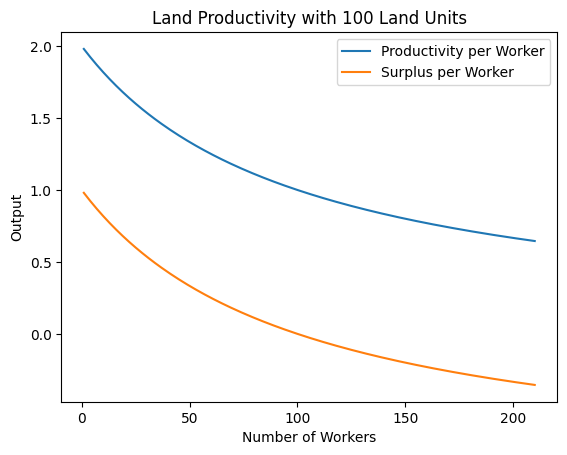

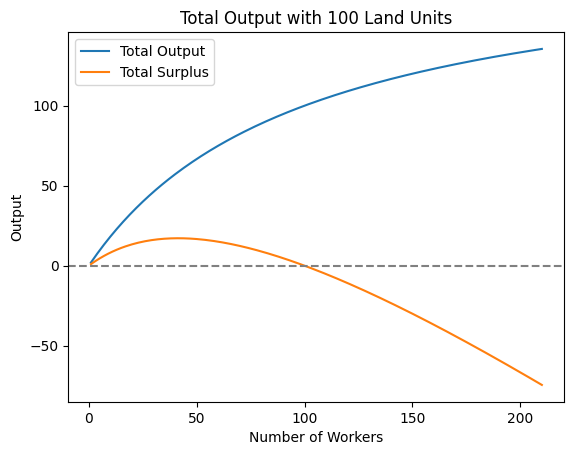

Surplus peaks at 41 workers with a surplus of 17.16
Zero crossing at 101 workers


C:\Users\white\AppData\Local\Temp\ipykernel_175976\2518650611.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


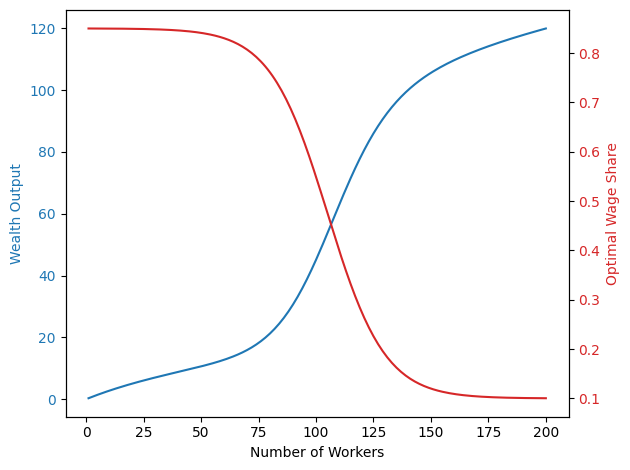

In [11]:
# Example usage and plotting
x_range = []
y_range_prod = []
y_range_rel_surplus = []
y_range_total = []
y_range_surplus = []

surplus_peak = 0
surplus_peak_value = 0
zero_crossing = 0
for x in range(210):
    land = 100
    workers = x + 1
    productivity = get_land_productivity(land, workers, base_productivity=2.0, saturation=1.0, exp=1.0)
    total_output = productivity * workers # Food per worker
    total_surplus = total_output - workers

    surplus_peak = workers if total_surplus > surplus_peak_value else surplus_peak
    surplus_peak_value = max(surplus_peak_value, total_surplus)
    zero_crossing = workers if total_surplus < 0 and zero_crossing == 0 else zero_crossing

    x_range.append(workers)
    y_range_prod.append(productivity)
    y_range_rel_surplus.append(total_surplus/workers)
    y_range_total.append(total_output)
    y_range_surplus.append(total_surplus)

x_range_elite_surplus = []
y_range_elite_optimal_wage = []
y_range_elite_wealth_output = []
for x in range(200):
    land_commoners = 20
    land_elites = 80
    commoners = x + 1

    optimal_wage = get_wage_share(commoners, jobs_count=land_elites+land_commoners, worker_owned_count=land_commoners, k=-8.0, d_crit=1.0)
    wealth_output = get_land_productivity(land_elites+land_commoners, commoners, base_productivity=2.0, saturation=1.0, exp=1.0) * (1 - optimal_wage) * commoners
    # optimal_wage, wealth_output = optimize_wage_share(land_elites, land_commoners, commoners, slaves=0, saturation=0.25, exp=3)
    x_range_elite_surplus.append(commoners)
    y_range_elite_optimal_wage.append(optimal_wage)
    y_range_elite_wealth_output.append(wealth_output)

plt.plot(x_range, y_range_prod, label="Productivity per Worker")
plt.plot(x_range, y_range_rel_surplus, label="Surplus per Worker")
plt.xlabel("Number of Workers")
plt.ylabel("Output")
plt.title("Land Productivity with 100 Land Units")
plt.legend()
plt.show()

plt.plot(x_range, y_range_total, label="Total Output")
plt.plot(x_range, y_range_surplus, label="Total Surplus")
plt.axhline(y=0, color='gray', linestyle='--') # zero line
plt.xlabel("Number of Workers")
plt.ylabel("Output")
plt.title("Total Output with 100 Land Units")
plt.legend()
plt.show()

print(f"Surplus peaks at {surplus_peak} workers with a surplus of {surplus_peak_value:.2f}")
print(f"Zero crossing at {zero_crossing} workers")

# Left axis: Wealth Output
# Right axis: Optimal Wage Share
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel("Number of Workers")
ax1.set_ylabel("Wealth Output", color=color)
ax1.plot(x_range_elite_surplus, y_range_elite_wealth_output, label="Wealth Output", color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for optimal wage share
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Optimal Wage Share", color=color)
ax2.plot(x_range_elite_surplus, y_range_elite_optimal_wage, label="Optimal Wage", color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
fig.show()

In [12]:
print(y_range_elite_optimal_wage)

[0.8498173475952012, 0.8498021390253038, 0.8497856644743685, 0.8497678186232833, 0.8497484874021503, 0.8497275472650864, 0.8497048644052551, 0.8496802939052537, 0.8496536788176068, 0.8496248491696904, 0.849593620886967, 0.8495597946279394, 0.8495231545237035, 0.849483466814445, 0.8494404783746224, 0.8493939151179579, 0.8493434802726779, 0.8492888525167347, 0.8492296839619663, 0.8491655979753548, 0.8490961868246657, 0.8490210091348548, 0.8489395871406545, 0.8488514037197474, 0.8487558991898692, 0.8486524678520662, 0.8485404542611857, 0.8484191492034675, 0.8482877853598727, 0.848145532632524, 0.8479914931103403, 0.8478246956486618, 0.8476440900363779, 0.847448540722812, 0.8472368200754231, 0.8470076011382545, 0.846759449860066, 0.8464908167602369, 0.8462000279999004, 0.8458852758254121, 0.8455446083512448, 0.8451759186498109, 0.8447769331166783, 0.84434519908122, 0.8438780716351301, 0.8433726996545442, 0.8428260109959312, 0.8422346968516812, 0.8415951952586178, 0.8409036737617942, 0.8401

In [408]:
class Pop:
    def __init__(self, name, n):
        self.name = name
        self.population = n
        self.wealth = 0.0
        self.wealth_level = 0
        self.desired_wealth_level = 0.0
        self.taxes = 0.0
        self.government_benefits = 0.0

class Simulation:
    def __init__(self):
        self.population = 0.0
        self.total_wealth = 0.0
        self.pops = {}
        self.land_area = 1000  # total arable land
        self.food_production_per_land = 2.0  # food produced per unit land
        self.food_consumption_per_capita = 1.0  # food consumed per person
        self.productivity = 1.0  # base productivity of land
        self.wealth_per_land = 1.0  # wealth generated per unit land
        self.common_land = 800.0
        self.elite_land = 200.0

        self.food_production = 0.0
        self.food_consumption = 0.0
        self.food_shortage = 0.0

        self.wage_share = 0.0
        
        # Popular Immiseration
        # The metric that tracks how much misery the common people experience
        # Sources from food shortages, wealth inequality, and decreases in wealth
        self.population_ratio = 0.0
        self.popular_immiseration = 0.0

        # Elite Overproduction
        # The metric that tracks how much overproduction the elite experience (relative to job opportunities).
        # Jobs are based on elite land, state employment, and business opportunities. Added to this is a 1% population buffer to represent lower level elite positions 
        self.elite_job_opportunities = 0.0
        self.elite_excess = 0.0
        self.elite_overproduction = 0.0

        # Sociopolitical Instability
        # The metric that tracks how much sociopolitical instability there is. This is influenced by popular immiseration and elite overproduction.
        # It only starts affecting the simulation once it's above state capacity
        # (Once above state capacity) It decreases state revenues, increases death/demotion rates (particularly of the elite), and decreases productivity
        self.sociopolitical_instability = 0.0
        self.effective_instability = 0.0

        # State Capacity
        # The metric that tracks how much state capacity there is. This represents the state's ability to maintain order and provide public goods.
        # The state collects revenues from taxing the elite and commoners, but it also has expenses from maintaining order and providing elites jobs. 
        # If expenses exceed revenues, debt increases which reduces state capacity.
        # Revenues also decrease when sociopolitical instability increases above state capacity, as the state is less able to collect taxes and maintain order.
        # Once the state collapses debt is reset to 0 to represent default. This also allows the state to potentially recover if conditions improve enough after collapse.
        self.state_capacity = 1.0
        self.taxation_rate_commoners = 0.0
        self.taxation_rate_elites = 0.0
        self.revenue = 0.0
        self.expenses = 0.0
        self.state_jobs = 0.0
        self.debt = 0.0
        
        self.population_history = []
        self.wealth_history = []
        self.security_history = []
        self.wage_share_history = []
        self.inequality_history = []
        self.elite_ratio_history = []
        self.state_capacity_history = []

        self.revenue_history = []
        self.expenses_history = []
    
    def add_pop(self, name, n):
        pop = Pop(name, n)
        self.pops[name] = pop
        self.population += n

    def adjust_population(self, name, delta):
        if name not in self.pops:
            return
        
        self.pops[name].population = max(0.0, self.pops[name].population + delta)
        self.population = max(0.0, self.population + delta)
    
    # Positive: Elites get land from commoners. Negative: Elites give land to commoners.
    def land_transfer(self, land: float):
        if land == 0:
            return
        
        # Bound land to the amount of land available for transfer
        land = max(-self.elite_land, min(self.common_land, land))

        self.common_land -= land
        self.elite_land += land
    
    def social_mobility(self, pop: float, land_rate: float = 2.0):
        if pop == 0:
            return

        # Bound pop to the amount of population available for promotion
        pop = max(-self.pops["Elites"].population, min(self.pops["Commoners"].population, pop))

        self.pops["Commoners"].population -= pop
        self.pops["Elites"].population += pop

        # Portion of land goes with the promoted/demoted pops. Land rate determines disproportionality of land transfer.
        if land_rate == 0:
            return

        if pop > 0:
            land_transfer_amount = (pop / self.pops["Commoners"].population) * self.common_land * land_rate if self.pops["Commoners"].population > 0 else 0.0
        else:
            land_transfer_amount = -1 * (pop / self.pops["Elites"].population) * self.elite_land / land_rate if self.pops["Elites"].population > 0 else 0.0
        self.land_transfer(land_transfer_amount)

    def get_inequality(self):
        elite_per_capita = self.pops["Elites"].wealth / self.pops["Elites"].population if self.pops["Elites"].population > 0 else 0.0
        commoner_per_capita = self.pops["Commoners"].wealth / self.pops["Commoners"].population if self.pops["Commoners"].population > 0 else 0.0

        return elite_per_capita / commoner_per_capita if commoner_per_capita > 0 else float('inf')
    
    def get_elite_ratio(self):
        elite_population = self.pops["Elites"].population if "Elites" in self.pops else 0.0
        common_population = self.pops["Commoners"].population if "Commoners" in self.pops else 0.0

        return elite_population / common_population if common_population > 0 else float('inf')
    
    def default_setup(self):
        #self.add_pop("Slaves", 200, 0)
        self.add_pop("Commoners", 300)
        #self.add_pop("Urbanites", 200, 0)
        self.add_pop("Elites", 4)

        self.taxation_rate_commoners = 0.1
        self.taxation_rate_elites = 0.2

        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))
        self.micro_economy_step()
        self.state_capacity_step()
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth + pop.government_benefits - pop.taxes)
            pop.desired_wealth_level = pop.wealth_level
    
    def micro_economy_step(self):
        # Commoner Allocation
        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        
        commoner_land_pull = self.productivity * self.land_jobs * (self.common_land / self.land_area)
        elite_land_pull = self.productivity * self.land_jobs * (self.elite_land / self.land_area) * ((1+self.wage_share) / 2.0)
        
        self.land_pull = commoner_land_pull + elite_land_pull
        self.total_commoner_pull = self.land_pull # for now, we can add other pulls (like urban jobs) to this in the future

        self.commoners_on_land = self.pops["Commoners"].population * (self.land_pull / self.total_commoner_pull) if self.total_commoner_pull > 0 else 0.0

        # Production
        prod_final = self.productivity
        land_prod = get_land_productivity(self.land_area, self.commoners_on_land, base_productivity=prod_final) * self.commoners_on_land
        
        # Wealth Allocation
        # From Work
        work_value = land_prod * self.wealth_per_land
        self.pops["Commoners"].wealth = work_value * self.wage_share
        
        # From Ownership
        self.pops["Commoners"].wealth += work_value * (1 - self.wage_share) * (self.common_land / self.land_area) 
        self.pops["Elites"].wealth = work_value * (1 - self.wage_share) * (self.elite_land / self.land_area) 
        self.total_wealth = work_value
        
        # Food Calculation
        self.food_production = land_prod * self.food_production_per_land
        self.food_consumption = sum(pop.population * self.food_consumption_per_capita for pop in self.pops.values())
        self.food_shortage = max(0.0, self.food_production - self.food_consumption) / self.food_consumption if self.food_consumption > 0 else 0.0

    def popular_immiseration_step(self):
        popular_immiseration = self.food_shortage * 0.5 + max(0.0, (self.pops["Commoners"].desired_wealth_level - self.pops["Commoners"].wealth_level) * 0.2)
        
        # Any shortage causes misery
        if self.food_shortage > 0.0:
            popular_immiseration += 0.1

        # Populace become content with their desired wealth level (also helps get PI to 0)
        if self.pops["Commoners"].wealth_level > self.pops["Commoners"].desired_wealth_level:
            popular_immiseration -= 0.1
        
        self.popular_immiseration = min(max(0.0, self.popular_immiseration * 0.5 + popular_immiseration * 0.5), 1.0) # smoothing
        self.population_ratio = self.population / (self.land_area * self.productivity) if (self.land_area * self.productivity) > 0 else float('inf')

    def elite_overproduction_step(self):
        buffer = 0.005 * self.population
        self.elite_job_opportunities = self.elite_land * 0.01 * self.productivity + self.state_jobs + buffer
        self.elite_excess = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities + self.state_jobs)
        self.elite_overproduction = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities) / (self.elite_job_opportunities + 1e-8)
        
    def sociopolitical_instability_step(self):
        self.sociopolitical_instability = self.popular_immiseration * 0.5 + self.elite_overproduction * 0.5
        effective_instability = min(max(0.0, self.sociopolitical_instability - self.state_capacity), 1.0)
        if self.sociopolitical_instability < self.state_capacity:
            effective_instability = -0.1

        self.effective_instability = self.effective_instability * 0.5 + effective_instability * 0.5 # smoothing
    
    def state_capacity_step(self):
        repression = self.sociopolitical_instability - self.effective_instability
        effective_taxation_rate_commoners = self.taxation_rate_commoners * (1.0 - self.effective_instability)
        effective_taxation_rate_elites = self.taxation_rate_elites * (1.0 - self.effective_instability)
        
        self.pops["Commoners"].taxes = effective_taxation_rate_commoners * self.pops["Commoners"].wealth
        self.pops["Elites"].taxes = effective_taxation_rate_elites * self.pops["Elites"].wealth

        elite_desired_wealth = wealth_req[round(self.pops["Elites"].desired_wealth_level)]
        self.pops["Elites"].government_benefits = self.state_jobs * elite_desired_wealth

        interest = min(self.debt * 0.05, self.revenue * self.state_capacity) # State debt payments is 1/n^2 of its capacity. 
        # This means lower capacity is able to pay less, which represents the difficulty of paying debt during times of crisis. 
        # It also means that if the state collapses (capacity goes to 0), it effectively defaults on its debt.
        # It also makes it easier for the state to recover from collapse if conditions improve, as the debt burden is reduced during collapse.

        self.revenue = self.taxation_rate_commoners * self.pops["Commoners"].wealth + self.taxation_rate_elites * self.pops["Elites"].wealth
        self.expenses = self.state_jobs * elite_desired_wealth + interest + repression * self.population * elite_desired_wealth * 0.1
        

    def adjustments_step(self):
        # Government adjustments
        self.state_jobs = (self.pops["Elites"].population * 0.05 + self.elite_excess) * self.state_capacity # Military + State tries to absorb excess elite population

        net_budget = self.revenue - self.expenses
        if net_budget < 0:
            if self.debt * 0.05 < self.revenue * self.state_capacity:
                self.debt += -net_budget
        else:
            self.debt = max(0.0, self.debt - net_budget) # Pay down debt if there's a surplus

        if self.state_capacity > 0.0:
            # Adjust taxes based on revenues
            if self.revenue < self.expenses:
                self.taxation_rate_commoners = min(0.25, self.taxation_rate_commoners + 0.01)
                self.taxation_rate_elites = min(0.5, self.taxation_rate_elites + 0.02)
            elif self.revenue > self.expenses * 1.2: # If there's a large surplus, consider lowering taxes
                self.taxation_rate_commoners = max(0.05, self.taxation_rate_commoners - 0.01)
                self.taxation_rate_elites = max(0.1, self.taxation_rate_elites - 0.02)
        
        debt_payment_capacity = self.revenue * self.state_capacity
        debt_payment = self.debt * 0.05

        state_capacity_change = 0.1 + 0.1 * (net_budget / (self.expenses + 1e-8)) - 0.1 * (debt_payment * 2 / (debt_payment_capacity + 1e-8) - 1)
        self.state_capacity = max(0.0, min(1.0, self.state_capacity + state_capacity_change))

        # Wage Adjustment
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))

        # Goods Shortages and Population Growth
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth - pop.taxes + pop.government_benefits) # Wealth level is based on disposable wealth after taxes and benefits
            shortage_modifier = get_shortage_modifier(pop.wealth_level, self.food_shortage)
            population_change = pop.population * 0.01 + 0.001 * pop.wealth_level  # Base growth plus wealth-based growth
            if shortage_modifier > 0.0:
                population_change -= pop.population * shortage_modifier * 0.1  # 10% of the effective shortage impacts population
            if pop.name == "Elites":
                population_change -= self.effective_instability * pop.population * 0.05 # Elites are more affected by instability, which can cause death or demotion
            self.adjust_population(pop.name, population_change)
        
        # Elites downgrade when they're poor
        if self.get_inequality() < 5.0:
            rate = -0.2 * (5.0 - self.get_inequality())
            self.social_mobility(pop=rate * self.pops["Elites"].population, land_rate=2.0)

        # New elites form from commoners
        if self.common_land > 0.0 and self.effective_instability < 0.25:
            rate = 0.01 * self.get_inequality()
            self.social_mobility(pop=rate * (self.pops["Commoners"].population * 0.01 + self.pops["Elites"].population), land_rate=20.0)

            if self.elite_job_opportunities - self.state_jobs > self.pops["Elites"].population:
                self.social_mobility(pop=self.elite_job_opportunities * 0.01, land_rate=20.0)

        # Correct values in case of issues
        self.population = sum(pop.population for pop in self.pops.values())
        
    def record_history(self):
        total_population = sum(pop.population for pop in self.pops.values())
        total_wealth = sum(pop.wealth for pop in self.pops.values())
        security = 1 - self.effective_instability
        inequality = self.get_inequality()
        elite_ratio = self.get_elite_ratio()

        self.population_history.append(total_population)
        self.wealth_history.append(total_wealth)
        self.security_history.append(security)
        self.wage_share_history.append(self.wage_share)
        self.inequality_history.append(inequality)
        self.elite_ratio_history.append(elite_ratio)
        self.state_capacity_history.append(self.state_capacity)

        self.revenue_history.append(self.revenue)
        self.expenses_history.append(self.expenses)

    def step(self, step=0, verbose=False):
        self.micro_economy_step()
        self.popular_immiseration_step()
        self.elite_overproduction_step()
        self.sociopolitical_instability_step()
        self.state_capacity_step()
        self.adjustments_step()
        self.record_history()

        if verbose:
            print(f"Step {step}: Population: {self.population:.0f}, Wealth: {self.total_wealth:.2f}, Food Shortage: {self.food_shortage:.2%}, Wage Share: {self.wage_share:.2%}, Inequality: {self.get_inequality():.2f}, Elite Ratio: {self.get_elite_ratio():.4f}, State Capacity: {self.state_capacity:.2f}, Sociopolitical Instability: {self.sociopolitical_instability:.2f}")


NEXT: 
Add in the state (state land - shares workers with elite land)
Add in elite extraction bonus/malus (two different wages - one for equalization, the other for extraction)
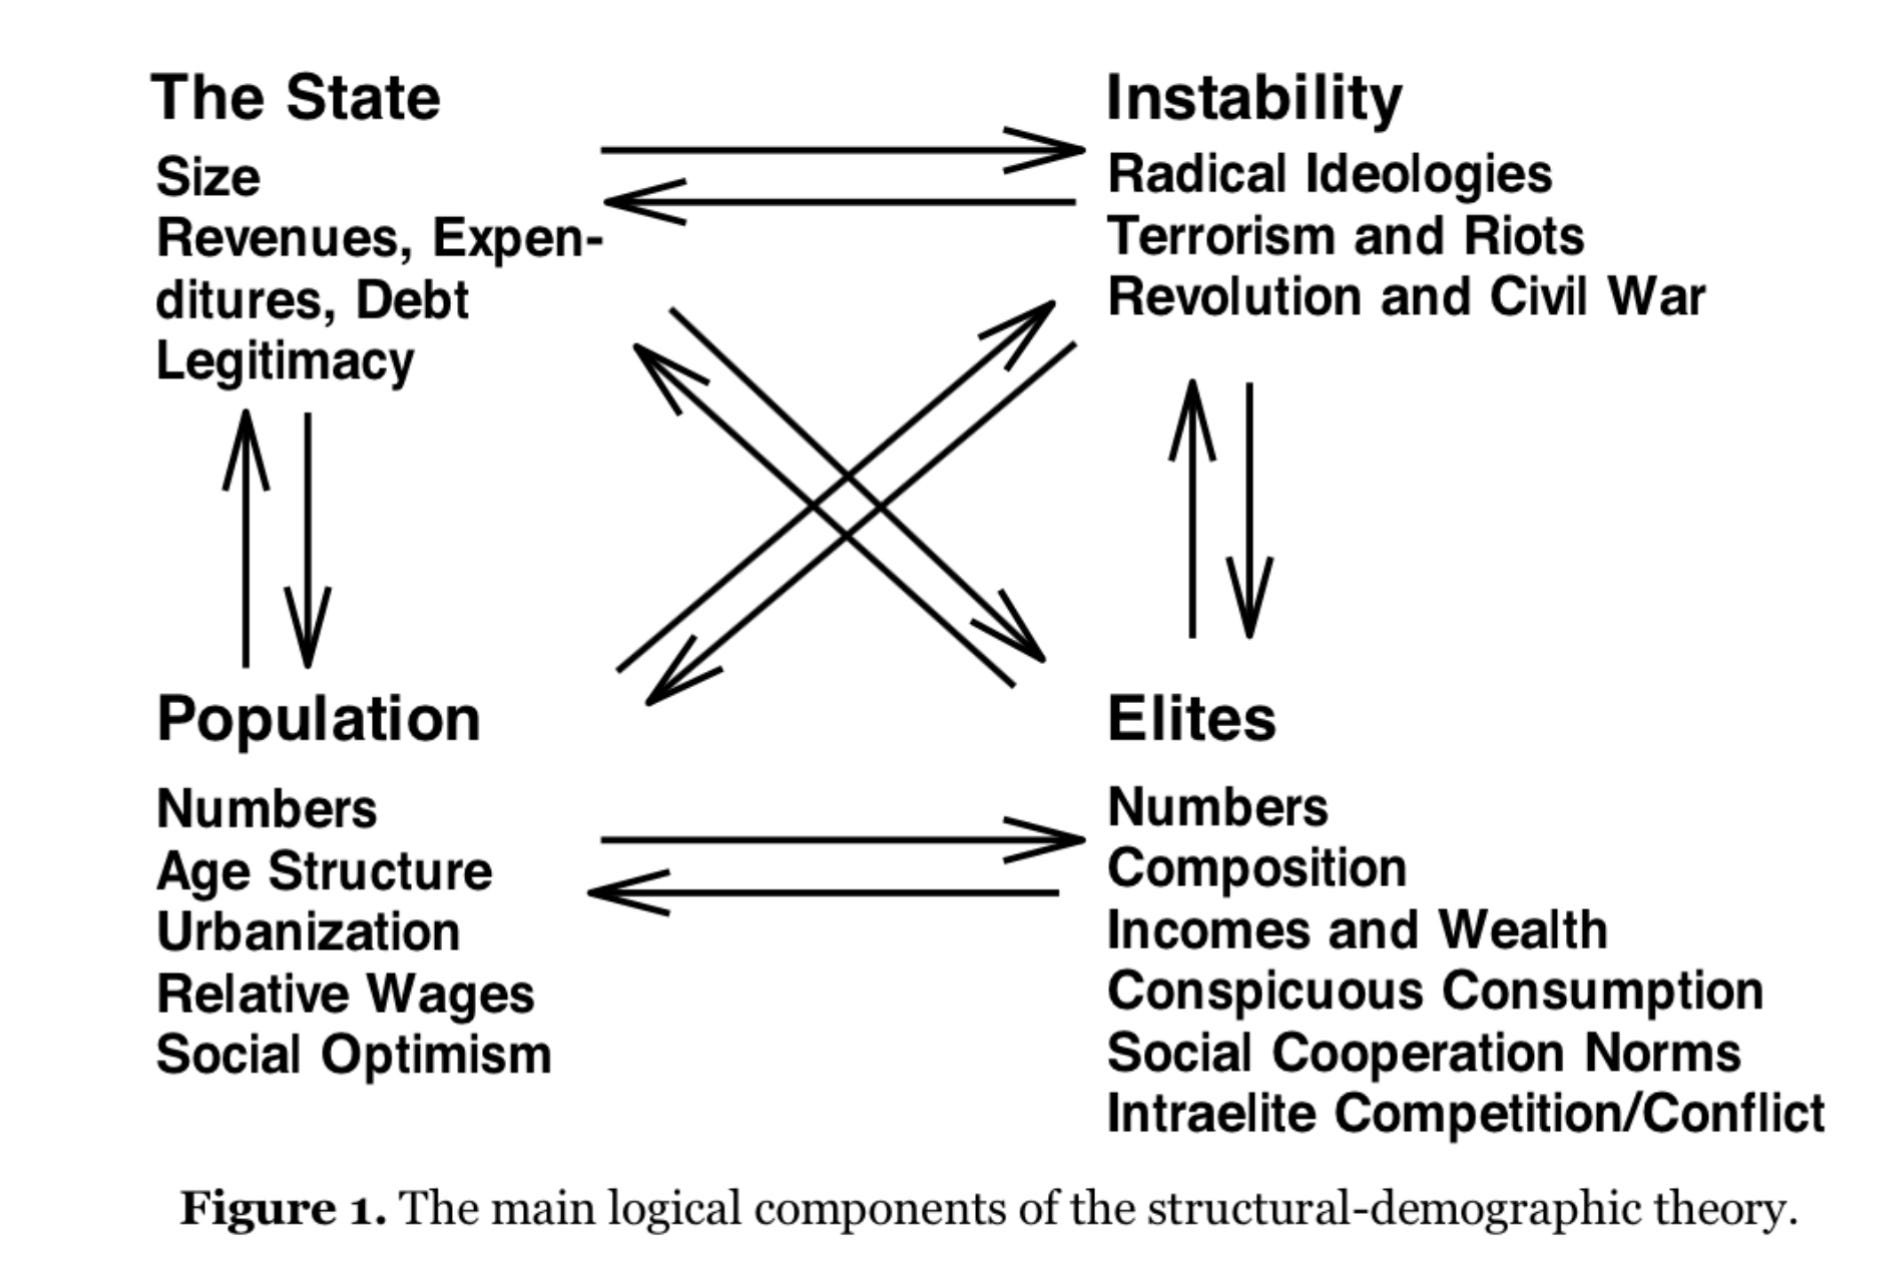

Investment:
    A portion of wealth in excess of expected wealth level rounded up gets put into an investment pool separated by pop type
    Those pops then use that money to invest in production & capital
    Pops in a location might decide to locally fund certain nonproductive enterprises by themselves depending on conditions (education, housing, security)

Popular immiseration:
    desired_wealth = 20-year moving average of actual wealth per commoner
        desired_new = desired_old + 0.05 * (current wealth - desired_old)
    base_immiseration = max(0, desired_wealth - current_wealth_per_commoner) * 0.2
    spike from shortages: +1.0 from 100% shortage
    Final = clamp (0-1) and smooth

Elite Overproduction:
    elite_job_opportunities = (total_elite_positions) + buffer
        elite_positions = elite_land / avg_elite_land_per_capita + state_employment_slots + business_slots
        buffer = 1 % of total population
    
    elite_overproduction = max(0, (elite_numbers - elite_job_opportunities) / elite_job_opportunities)

Sociopolitical Instability
    Instability = immiseration + elite overproduction
    Father and son pulse: Add/remove every 20ish years

State Capacity
    Revenue = (commoner_wealth * tax_rate_common) + (elite_surplus * tax_rate_elite)
    Spending = (elite_job_opportunities * cost_per_elite) + (military + repression) + (debt_service)
    Balance = Revenue - Spending
    Debt = Debt_old + max(0, -Annual_balance)
    State_capacity_new = (1-Debt/GDP_proxy) + (1-immiseration)


In [102]:
sim = Simulation()
sim.default_setup()
random.seed(42)
for step in range(101):
    sim.step(step=step, verbose=True)

plt.plot(sim.population_history, label="Total Population")
plt.plot(sim.wealth_history, label="Total Wealth")
plt.legend()
plt.show()

plt.plot(sim.security_history, label="Security")
plt.plot(sim.wage_share_history, label="Wage Share")
plt.plot(sim.state_capacity_history, label="State Capacity")
plt.legend()
plt.show()

plt.plot(sim.inequality_history, label="Inequality")
plt.legend()
plt.show()

plt.plot(sim.elite_ratio_history, label="Elite Ratio")
plt.legend()
plt.show()

plt.plot(sim.revenue_history, label="Revenue")
plt.plot(sim.expenses_history, label="Expenses")
plt.legend()
plt.show()

NameError: name 'Simulation' is not defined

In [614]:
# Simplified version of Secular Cycles with just the core feedback loops, to test the dynamics of the model and see if it can generate realistic cycles of growth and collapse.
# It has four main variables (from 0.0 to 1.0):
# P - Population: Population relative to carrying capacity. Affected by food shortages and wealth levels. Below 0.5 is below carrying capacity, above 0.5 is above carrying capacity.
# E - Elite Overproduction: The level of elite overproduction relative to elite job opportunities. Affected by population and elite land. Above 0.0 means elites are overproducing relative to job opportunities.
# U - Sociopolitical Instability: The level of sociopolitical instability. Its effect is U^2. 0.0 means stable peace, 1.0 means civil war.
# S - State Capacity: How much the state is able to act, coerce the population, and provide public goods. 1.0 means strong and stable state, 0.0 means de-facto anarchy
#
# P:
# Supply curve to State Capacity
# Kept low by U
# E:
# Increases when P is high
# Shrinks via U
# U:
# Increases when E is high
# Shrinks when S is high
# Spikes every 40-50 years (father son cycle)
# S:
# Increases when P is high
# Decreases when U is high
# Decreases when E is high (state employing overproduced elites)
#
# Rotating Influences:
# P, S naturally grows
# P increases E (more population creates more elites)
# E decreases S (overproduced elites require state resources and create instability)
# P, E, and less S increase U (overpopulation, elite overproduction, and low state capacity all contribute to instability)
# U decreases S, E, and P

class SimpleSim:
    def __init__(
            self, 
            P=0.4, # Starting Population
            E=0.1, # Starting Elite Overproduction
            S=0.5, # Starting State Capacity
            dP_mult=1.0, # Growth multipliers
            dE_mult=1.0, 
            dS_mult=1.0, 
            dP_nmult=0.5, # Shrink multipliers (when growth is negative)
            dE_nmult=0.5, 
            dS_nmult=2.0
        ):
        self.P = P  # Population
        self.E = E  # Elite Overproduction
        self.U = 0.0  # Sociopolitical Instability
        self.U_e = 0.0  # Effective Instability (instability above state capacity)
        self.S = S  # State Capacity
        self.instability_memory = 0.0 # Memory of past instability to create inertia in the system
        
        self.phase = 0 # 0 = prosperity, 1 = strain, 2 = fracture
        
        # Random value multipliers that change every 10 steps since adjusting randomness every step cancels out the effect.
        self.P_rand = 0.0
        self.E_rand = 0.0
        self.U_rand = 0.0
        self.S_rand = 0.0

        self.P_history = []
        self.E_history = []
        self.U_history = []
        self.U_e_history = []
        self.S_history = []
        self.phase_history = []

        # Multipliers
        self.dP_mult = dP_mult
        self.dE_mult = dE_mult
        self.dS_mult = dS_mult
        self.dP_nmult = dP_nmult
        self.dE_nmult = dE_nmult
        self.dS_nmult = dS_nmult
    
    def step(self, t, randomness=0.0):

        # Population growth is based on a logistic growth model with carrying capacity influenced by state capacity and effective instability.
        carrying_cap = min(max(0.5 + self.S**2 - self.U_e * 1.0, 0.0), 1.0)
        dP = (self.P + 0.1) * (carrying_cap - self.P)
        if dP > 0:
            dP *= self.P * (1.1 - self.P) / 1.1 # Population grows slower as it approaches carrying capacity
            dP *= self.dP_mult
        else:
            dP *= (self.P+0.1)/1.1 # Population shrinks slower as it approaches 0.0
            dP *= self.dP_nmult

        
        # Elite overproduction increases with population pressure (so long as the state exists)
        # It decreases with effective instability as well as low population pressure representing how elites are the targets of violence and also high wages squeezing elite wealth.
        dE = (self.P**2 * max(0.0, self.S - self.U_e) - self.U_e**2 + min(0.0, self.P - 0.5) * 0.25)
        if dE > 0:
            dE *= (1.1 - self.E)/1.1
            dE *= self.dE_mult
        else:
            dE *= (self.E+0.2)/1.2
            dE *= self.dE_nmult

        # Sociopolitical instability increases with elite overproduction and population pressure, and decreases with state capacity. 
        # TODO: It also has periodic spikes every 40-50 years to represent father-son cycles of violence.
        #dU = (self.E - self.S + (t % 50 < 5) - 0.8 * self.U) * dU_mult
        immiseration = max(0.0, self.P - carrying_cap * 0.5) * 2 + self.E * 0.2 # Immiseration starts when population exceeds 50% of carrying capacity
        p_mobilization = min(1.0, immiseration + math.sqrt(self.instability_memory) * 0.5) # Population mobilization is based on current immiseration and memory of past instability
        e_mobilization = min(1.0, self.E + math.sqrt(self.instability_memory) * 0.5)
        unrest = p_mobilization * e_mobilization * (1 - self.S)
        dU = 0 #(-0.5 + 1 * (t % 50 < 5) - self.S) * dU_mult # Father-son cycles added to unrest equation

        # State capacity increases with population pressure and decreases with elite overproduction and sociopolitical instability. It also has a baseline growth to represent the desire to have a state.
        dS = (0.0 + self.P*(1.0 - self.U_e) - self.U_e**2 - self.E*(self.S+0.1))
        if dS > 0:
            dS *= (1.5 - self.S)/1.5
            dS *= self.dS_mult
        else:
            dS *= (self.S+0.2)/1.2
            dS *= self.dS_nmult

        # Randomness to represent unmodeled factors and add variability to the system
        if randomness > 0.0:
            if t % 10 == 0: # Adjust randomness every 10 steps to create periods of stability and instability
                self.P_rand = random.uniform(-randomness, randomness) + 1
                self.E_rand = random.uniform(-randomness, randomness) + 1
                self.U_rand = random.uniform(-randomness, randomness) + 1
                self.S_rand = random.uniform(-randomness, randomness) + 1
            
            dP *= self.P_rand
            dE *= self.E_rand
            unrest *= self.U_rand
            dS *= self.S_rand

        # Update variables with some smoothing
        self.P = max(0.0, min(1.0, self.P + dP * 0.1))
        self.E = max(0.0, min(1.0, self.E + dE * 0.1))
        self.U = max(0.0, min(1.0, self.U + dU * 0.1))
        self.S = max(0.0, min(1.0, self.S + dS * 0.1))

        self.U_e = max(0.0, min(unrest + self.U, 1.0)) # Effective instability is instability above 0.5 * state capacity
        if self.U_e > self.instability_memory:
            self.instability_memory = self.U_e
        else:
            self.instability_memory *= 0.95 # Instability memory decays over time, creating inertia in the system
            self.instability_memory = max(self.U_e, self.instability_memory-0.02) # Instability memory has a baseline decay to prevent it from getting stuck at high levels forever
        
        # Phase transitions
        if self.phase == 0 and (self.U > 0.1 or self.E > 0.5 or self.P > 0.7):
            self.phase = 1
        elif self.phase == 1 and (self.U_e > 0.5 or self.S < 0.5 or (dE < 0 and dP < 0)):
            self.phase = 2
        elif self.phase == 2 and (self.U_e < 0.05 and dP > 0 and self.S > 0.2):
            self.phase = 0

        # Record history
        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.U_e_history.append(self.U_e)
        self.S_history.append(self.S)
        self.phase_history.append(self.phase)

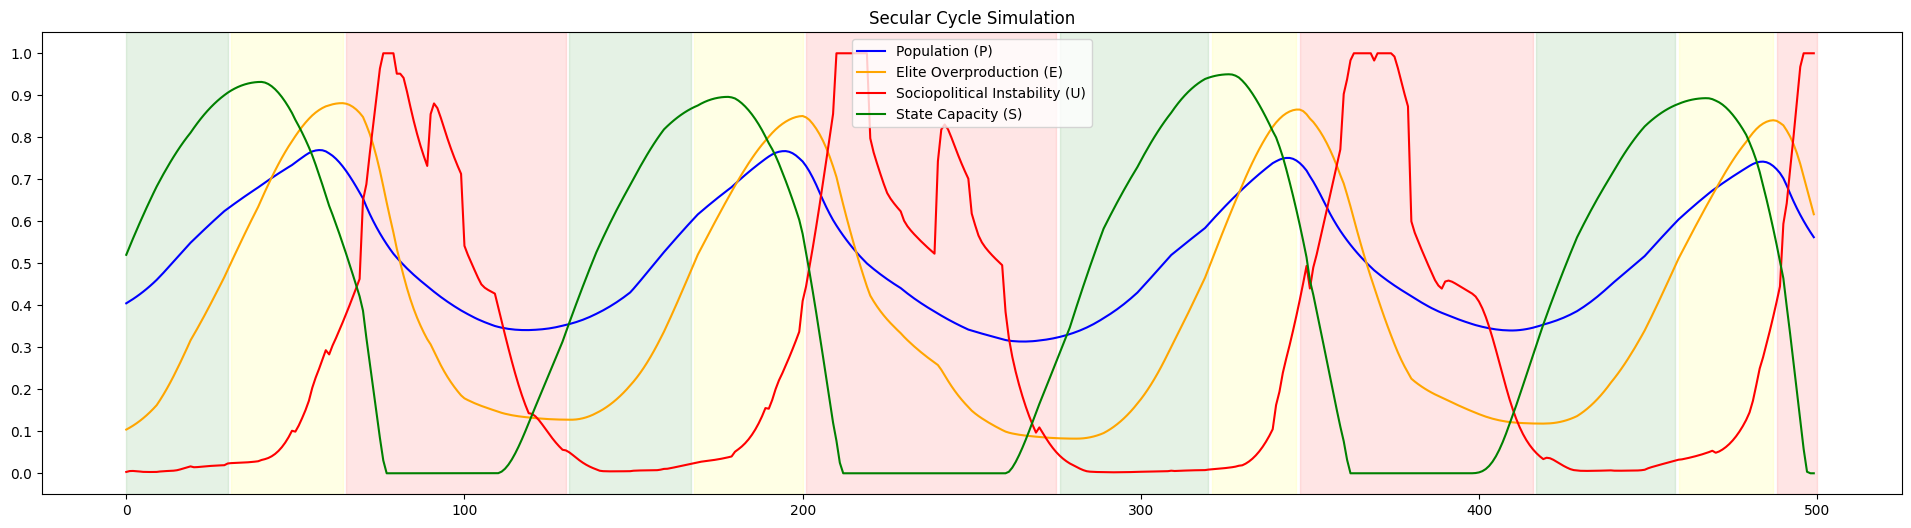

In [625]:
def plot_phase_space(phase_history=[]):
    # build phase space plot to color the background based on the phase of the system
    # Phase 0 = prosperity (green), Phase 1 = strain (yellow), Phase 2 = fracture (red)
    phase_types = []
    phase_starts = [0]
    phase_ends = []
    for x in range(0, len(phase_history)-1):
        if phase_history[x] != phase_history[x+1]:
            phase_types.append(phase_history[x])
            phase_ends.append(x)
            phase_starts.append(x+1)
    phase_types.append(phase_history[-1])
    phase_ends.append(len(phase_history))
    
    for x in range(len(phase_types)):
        if phase_types[x] == 0:
            plt.axvspan(phase_starts[x], phase_ends[x], color='green', alpha=0.1)
        elif phase_types[x] == 1:
            plt.axvspan(phase_starts[x], phase_ends[x], color='yellow', alpha=0.1)
        elif phase_types[x] == 2:
            plt.axvspan(phase_starts[x], phase_ends[x], color='red', alpha=0.1)

def plot_simulation(
    P_history, E_history, U_history, S_history, phase_history
):
    # Implementation for plotting the simulation results
    plt.figure(figsize=(24, 6))
    plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    plt.plot(P_history, label="Population (P)", color='blue')
    plt.plot(E_history, label="Elite Overproduction (E)", color='orange')
    plt.plot(U_history, label="Sociopolitical Instability (U)", color='red')
    plt.plot(S_history, label="State Capacity (S)", color='green')
    plot_phase_space(phase_history)
    plt.legend()
    plt.title("Secular Cycle Simulation")
    plt.show()
    pass

random.seed(42)

simple_sim = SimpleSim(
    P=0.4,
    E=0.1,
    S=0.5,
    dP_mult=1.0,
    dE_mult=1.0,
    dS_mult=1.0,
    dP_nmult=0.5,
    dE_nmult=0.5,
    dS_nmult=2.0
)
for t in range(500):
    simple_sim.step(t, randomness=0.2)

plot_simulation(    
    simple_sim.P_history, simple_sim.E_history, simple_sim.U_e_history, simple_sim.S_history, simple_sim.phase_history
)

In [ ]:
# Recombined Model for Secular Cycles
# This model takes the former simulation and adds the core feedback loops from the simple model to create a complex, realistic, and faithful model of secular cycles.
# It has the same variables as the original simulation, but with added feedback loops and interactions based on the simple model. 
# The goal is to see if the complex model can generate realistic cycles of growth and collapse similar to the simple model, while also capturing the nuances of the original simulation.
# This will be the core of what I use as the baseline mechanics for my game, and I can add more complexity and features on top of this in the future.

# DYNAMICS TO REPLICATE:
#   These are the dynamics coded into the simple model that I want to replicate in the complex model. Certain particular relationships may be directly represented, and others will be emergent.
#   But in general these are the mathematical relationships coded above:
#
# P:
#   Carrying Capacity = 0.5 + S^2 - U_e
#   dP = (P + 0.1) * (Carrying Capacity - P)
#   immiseration = max(0, P - Carrying Capacity * 0.5) * 2 + E * 0.2
#
#   Carrying Capacity is influenced positively by State Capacity and negatively by Effective Instability.
#   Population then changes as a logistic growth model based on the carrying capacity.
#   Immiseration starts when population exceeds 50% of carrying capacity, and also increases with elite overproduction.
#   REPRESENTING P:
#       Population grows at a rough 1% rate (historically 1% population growth was common during prosperous times) when conditions are good, but with immiseration births drop
#       Starvation (lack of food) and instability (U) then can directly kill population. Additional factors representing famine and disease would also be represented with immiseration.
#       Immiseration would be generated from a combination of factors such as food shortages, wealth decline (from expectation), elite overproduction, and inequality 
#           (which would intensify the effect such that even if the average wealth level of commoners is fine, if inequality is high, then a large portion of commoners would still be affected).
#       High population relative to job opportunities reduces the wage share, which increases inequality, decreases wealth of commoners, and as such increases immiseration.
#   HOW THIS REPLICATES THE SIMPLE MODEL:
#       Population growth would follow the near exponential curve of the early logistic model (though not exact, which is fine) with carrying capacity instead reflecting the output and productivity of the land and economy.
#       The latter half of the logistic growth curve would be reproduced via the effect of immiseration on population growth, even without instability directly killing population (as can be replicated in the simple model)
#       Immiseration only comes about as a result of high population putting pressure on resources. The more population there is, not only do resources become more scarce, 
#           but the wealth generated gets redirected increasingly towards elites, which furthers immiseration.
#       Final population pressure is then represented by the population relative to economic capacity with 0.5 being equality, thus recreating the variable P, only this isn't on a pure 0 to 1 scale as the upper amount is technically unbounded
#
# E:
#   dE = + P^2 * max(0, S - U_e) 
#        - U_e^2 
#        - max(0, 0.5 - P) * 0.25
#
#   Elite overproduction increases disproportionately with population pressure, but only when the state has the capacity (Condition existing to cut elite production to zero in times of crisis)
#   It decreases with instability as elites are the targets of violence in unstable times
#   It also decreases with low population pressure representing how high wages squeeze lower-end elites and force them to either downgrade or fight (the latter of which is not represented yet...)
#   REPRESENTING E:
#       Elites grow at a disproportionately fast rate compared to the population (likely 2%+) due to lower child mortality rates and greater access to resources, but bear less children when facing direct threat (instability).
#       Elites grow faster with higher inequality and can decline with low inequality.
#       Job opportunities for elites are based on elite land and state capacity. However the jobs provided for by the state only exist so long as the state can support them (based on state capacity, S).
#       Elites are disproportionately killed by instability, though are less affected by famine, disease, and other things that affect the general population.
#   HOW THIS REPLICATES THE SIMPLE MODEL:
#       Because when population is low, wages are high and thus the inequality measure pumps elites into commoners as elites cannot extract much surplus from the population. But when high, the opposite occurs.
#       The natural population growth from elites is also higher than commoners, which helps drive the growth of elites during prosperous times. This can be surpressed during times of instability and uncertainty, which can represent the S - U_e term.
#       Instability killing elites represents the - U_e^2 term. In-fact it'd almost be a direct copy.
#       Final elite overproduction is then represented by the number of excess elites relative to elites total, thus replicating the variable E.
#
# U:
#   Population Mobilization = min(1, Immiseration + sqrt(Instability Memory) * 0.5)
#   Elite Mobilization = min(1, E + sqrt(Instability Memory) * 0.5)
#   Unrest = Population Mobilization * Elite Mobilization * (1 - S)
#
#   Unrest is a function of popular and elite anger and state collapse. A strong state suppresses unrest, but when the state is weak, then unrest can grow based on how mobilized the population and elites are.
#   Mobilization for the population is based on immiseration and for elites, overproduction, but both are also influenced by memory of past instability to help prolong instability and create inertia in the system.
#   REPRESENTING U:
#       Unrest and instability would be based on a combination of popular immiseration and elite overproduction, as well as current state capacity.
#       Instability memory would be increased with current instabiltity to match it, but then when instability goes down, the memory would decay slowly over time.
#   HOW THIS REPLICATES THE SIMPLE MODEL:
#       It does, for the moment, nothing different than the simple model. This may change as I add in "security" and "control" to locations, but for now it's a direct copy.
#       Any future changes will have to preserve the dynamics here, though that should be relatively easy as this is a pretty straightforward relationship. 
#       And the only thing that would change is the (1-S) term, of which the only change might literally be that S goes from meaning "State Capacity" to "Security" where security is itself partially derived from state capacity (but other factors too) 
#
# S:
#   dS = + P*(1.0 - U_e) 
#        - U_e^2 
#        - E*(S+0.1)
#
#   State capacity grows with population pressure, representing taxation, but collection is less effective with high instability
#   It decreases with unrest due to the cost of suppression and with elite overproduction taking state resources (though this is not a factor when the state doesn't exist - allowing the state to exist partially in the fracture phase)
#   REPRESENTING S:
#       State capacity is not necessarily a simulation variable in of itself (as it is in the simple model), but emerges from the fiscal, miltary, and administrative abilities of the state
#       The state collects revenue in the form of taxing wealth generated from economic activity, so higher population = more economic activity = more revenue for the state. 
#       This is modulated by instability where high instability reduces the state's ability to collect taxes (represented by the effective taxation rate)
#           This will eventually be determined on a location by location basis based on the control and security of the location as well as if it's actually controlled (say in a civil war, occupation, or rebellion scenario)
#       The State then spends its revenue on a combination of military and public goods.
#           When instability is high, more of the state's resources are diverted towards repression and suppression of unrest
#           When you have excess elites, the state will try to employ them to keep them from causing trouble. 
#               In game this can actually potentially temporarily increase military capabilities (to a point, as overproduced elites can bicker with each other. See France during the Hundred Years War)
#       When the state spends more than it earns, it accumulates debt. At a certain point, it is deemed too risky to lend to, which can lead to default, and thus the inability to suppress unrest or pay for public goods and elite jobs
#       State capacity is thus one of the most complicated variables to derive, as it is based on a combination of revenue, expenses, debt, and the ability to effectively use resources to suppress unrest and provide public goods.
#           Fiscal Capacity = 0.5 * (Ordinary Revenue + Extraordinary Revenue - Expenses) / Expenses + (Debt Capacity + Savings - Debt) / (Debt Capacity + 2 * Expenses)
#           Ordinary Revenue = Taxation Rate * Wealth Generated by Population
#           Extraordinary Revenue = Revenue that *can* be derived from the state 1. hiking taxes, 2. printing money/debasing currency, 3. seizing wealth from elites, 4. selling off state assets. Each calculated to roughly account what can be done in one tick.
#               Using extraordinary revenues will decrease the ability to use them in the near-term future and possibly cause long-term problems. Some are less problematic (hiking taxes) but their use can heavily deteriorate medium-term fiscal capacity.
#           Expenses = Cost of government + repression + employing elites + interest on debt
#           Debt Capacity = The amount of debt the state can take on before lenders refuse to lend
#           Debt = Accumulated debt from previous deficits
#           Savings = When the state has a surplus in excess of debt, it can save up to 2 times its expenses. This helps represent ancient states' reliance on saving up to go fight wars or handle crises.
#           When the state has a deficit, it can take on debt up to its debt capacity. If it exceeds its debt capacity, it defaults.
#           NOTE: Depending on laws, default could also wipe out debt (like the repudiation of debt in medieval times), which would allow the state to recover capacity more quickly but hike interest rates and make it harder to borrow.
#                 So the severe US indebtedness is not indicative of typical situations.\
#        Coercion Capacity = Willingness & ability of the state to use violence to suppress unrest. For now it's set to 1.0, but will eventually be derived from army size, security, and other factors.
#        It is assumed so long as the state is able to pay its financial obligations, it will maintain all its administrative and welfare duties, but as fiscal capacity declines, its ability to pay will deteriorate.
#        Final State Capacity = Fiscal Capacity * Coercion Capacity
#   HOW THIS REPLICATES THE SIMPLE MODEL:
#       Because State Capacity is a derived value in the complex model, it is very different from the floating value in the simple model.
#       The increase of population increasing state capacity is represented by the increase in revenue from taxation (which then gets blocked by instability).
#       Unrest and elite overproduction increases state expenses, which can reduce state capacity if it leads to deficits and debt.
#       Whether the state chooses to no longer suppress violence or support elites, or it just can't because it defaults, the effect is the same in that it reduces state capacity.
#       Debt, Savings, and Extraordinary Revenues are all mechanics that help the state to manage or delay crises, but can make the crisis worse. 
#           Importantly, they cannot be used indefinitely. So their inclusion doesn't alter the dynamics, but adds more depth and realism to the model.

class RPop:
    def __init__(self, name, n):
        self.name = name
        self.population = n
        self.wealth = 0.0
        self.wealth_level = 0
        self.desired_wealth_level = 0.0
        self.taxes = 0.0
        self.government_benefits = 0.0

class RecombinedSim:
    def __init__(
            self, 
            commoner_pop=100, # Starting Commoner Population
            elite_pop=1.0, # Starting Elite Population
            land_area=100, # Starting Land Area
            elite_share=0.2, # Starting Elite Land Share
            dP_mult=1.0, # Growth multipliers (idk if these are necessary yet)
            dE_mult=1.0, 
            dS_mult=1.0, 
            dP_nmult=0.5, # Shrink multipliers (when growth is negative)
            dE_nmult=0.5, 
            dS_nmult=2.0
        ):
        # Simple Model Variables
        # These values will be derived from the base-truth simulation, but they will also feed back into the base-truth simulation to help replicate the dynamics of secular cycles.
        # They will also be used to graph the results and identify phases of the cycle, which can be used for game mechanics and events.
        self.P = 0.0  # Population
        self.E = 0.0  # Elite Overproduction
        self.U = 0.0  # Sociopolitical Instability
        self.S = 0.0  # State Capacity
        self.instability_memory = 0.0 # Memory of past instability to create inertia in the system
        
        self.phase = 0 # 0 = prosperity, 1 = strain, 2 = fracture

        self.P_history = []
        self.E_history = []
        self.U_history = []
        self.S_history = []
        self.phase_history = []

        # Base-Truth Simulation Variables
        self.population = 0.0
        self.total_wealth = 0.0
        self.pops = {}
        self.land_area = land_area  # total arable land
        self.food_production_per_land = 2.0  # food produced per unit land
        self.food_consumption_per_capita = 1.0  # food consumed per person
        self.productivity = 1.0  # base productivity of land
        self.wealth_per_land = 1.0  # wealth generated per unit land
        self.common_land = 800.0
        self.elite_land = 200.0

        self.food_production = 0.0
        self.food_consumption = 0.0
        self.food_shortage = 0.0

        self.wage_share = 0.0
        self.popular_immiseration = 0.0
        self.population_ratio = 0.0

        self.elite_job_opportunities = 0.0
        self.elite_excess = 0.0

        self.taxation_rate = 0.0 # Idk if I need to include a taxation rate per-se or if I can just calculate it based on the revenue needed to maintain state capacity, but I'll include it for now as a separate variable to make it easier to adjust and experiment with.
        self.revenue = 0.0
        self.expenses = 0.0
        self.state_jobs = 0.0
        self.debt = 0.0
        self.debt_capacity = 0.0
        self.savings = 0.0
        self.interest = 0.0
        self.extraordinary_revenue_exhaustion = 0.0 # A measure of how much the state has used extraordinary revenues recently

        # History for graphing & analysis
        self.population_history = []
        self.wealth_history = []
        self.wage_share_history = []
        self.inequality_history = []
        self.revenue_history = []
        self.expenses_history = []
        self.debt_history = []

        # Initialize Things
        self.add_pop("Commoners", commoner_pop)
        self.add_pop("Elites", elite_pop)

        self.taxation_rate = 0.2 # To note, commoner taxation is half of elite taxation.

        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))
        self.micro_economy_step()
        self.state_capacity_step()
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth + pop.government_benefits - pop.taxes)
            pop.desired_wealth_level = pop.wealth_level
    
    def add_pop(self, name, n):
        pop = RPop(name, n)
        self.pops[name] = pop
        self.population += n
    
    def adjust_population(self, name, delta):
        if name not in self.pops:
            return
        
        self.pops[name].population = max(0.0, self.pops[name].population + delta)
        self.population = max(0.0, self.population + delta)
    
    def land_transfer(self, land: float):
        if land == 0:
            return
        
        # Bound land to the amount of land available for transfer
        land = max(-self.elite_land, min(self.common_land, land))

        self.common_land -= land
        self.elite_land += land

    def social_mobility(self, pop: float, land_rate: float = 2.0):
        if pop == 0:
            return

        # Bound pop to the amount of population available for promotion
        pop = max(-self.pops["Elites"].population, min(self.pops["Commoners"].population, pop))

        self.pops["Commoners"].population -= pop
        self.pops["Elites"].population += pop

        # Portion of land goes with the promoted/demoted pops. Land rate determines disproportionality of land transfer.
        if land_rate == 0:
            return

        if pop > 0:
            land_transfer_amount = (pop / self.pops["Commoners"].population) * self.common_land * land_rate if self.pops["Commoners"].population > 0 else 0.0
        else:
            land_transfer_amount = -1 * (pop / self.pops["Elites"].population) * self.elite_land / land_rate if self.pops["Elites"].population > 0 else 0.0
        self.land_transfer(land_transfer_amount)
    
    def get_inequality(self):
        elite_per_capita = self.pops["Elites"].wealth / self.pops["Elites"].population if self.pops["Elites"].population > 0 else 0.0
        commoner_per_capita = self.pops["Commoners"].wealth / self.pops["Commoners"].population if self.pops["Commoners"].population > 0 else 0.0

        return elite_per_capita / commoner_per_capita if commoner_per_capita > 0 else float('inf')
    
    def get_elite_ratio(self):
        elite_population = self.pops["Elites"].population if "Elites" in self.pops else 0.0
        common_population = self.pops["Commoners"].population if "Commoners" in self.pops else 0.0

        return elite_population / common_population if common_population > 0 else float('inf')
    
    def micro_economy_step(self):
        # Commoner Allocation
        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        
        commoner_land_pull = self.productivity * self.land_jobs * (self.common_land / self.land_area)
        elite_land_pull = self.productivity * self.land_jobs * (self.elite_land / self.land_area) * ((1+self.wage_share) / 2.0)
        
        self.land_pull = commoner_land_pull + elite_land_pull
        self.total_commoner_pull = self.land_pull # for now, we can add other pulls (like urban jobs) to this in the future

        self.commoners_on_land = self.pops["Commoners"].population * (self.land_pull / self.total_commoner_pull) if self.total_commoner_pull > 0 else 0.0

        # Production
        prod_final = self.productivity
        land_prod = get_land_productivity(self.land_area, self.commoners_on_land, base_productivity=prod_final) * self.commoners_on_land
        
        # Wealth Allocation
        # From Work
        work_value = land_prod * self.wealth_per_land
        self.pops["Commoners"].wealth = work_value * self.wage_share
        
        # From Ownership
        self.pops["Commoners"].wealth += work_value * (1 - self.wage_share) * (self.common_land / self.land_area) 
        self.pops["Elites"].wealth = work_value * (1 - self.wage_share) * (self.elite_land / self.land_area) 
        self.total_wealth = work_value
        
        # Food Calculation
        self.food_production = land_prod * self.food_production_per_land
        self.food_consumption = sum(pop.population * self.food_consumption_per_capita for pop in self.pops.values())
        self.food_shortage = max(0.0, self.food_production - self.food_consumption) / self.food_consumption if self.food_consumption > 0 else 0.0

    def popular_immiseration_step(self):
        popular_immiseration = (
            self.food_shortage * 0.5 
            + max(0.0, (self.pops["Commoners"].desired_wealth_level - self.pops["Commoners"].wealth_level) * 0.2)
            + max(0.0, self.E - 0.25) * 0.2
        )
        popular_immiseration *= max(1.0, math.log(self.get_inequality() + 1) - 2.4) # Inequality intensifies immiseration after about a 10:1 ratio between elites and the rest of the population.
        popular_immiseration = max(min(popular_immiseration, 1.0), 0.0)
        
        # Any shortage causes misery
        if self.food_shortage > 0.0:
            popular_immiseration += 0.1

        # Populace become content with their desired wealth level (also helps get PI to 0)
        if self.pops["Commoners"].wealth_level > self.pops["Commoners"].desired_wealth_level:
            popular_immiseration -= 0.1
        
        self.popular_immiseration = min(max(0.0, self.popular_immiseration * 0.5 + popular_immiseration * 0.5), 1.0) # smoothing
        self.population_ratio = self.population / (self.land_area * self.productivity) if (self.land_area * self.productivity) > 0 else float('inf')

    def elite_overproduction_step(self):
        buffer = 0.005 * self.population
        self.elite_job_opportunities = self.elite_land * 0.01 * self.productivity + self.state_jobs + buffer
        self.elite_excess = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities + self.state_jobs)
        self.elite_overproduction = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities) / (self.elite_job_opportunities + 1e-8)
        
    def sociopolitical_instability_step(self):
        self.sociopolitical_instability = self.popular_immiseration * 0.5 + self.elite_overproduction * 0.5
        effective_instability = min(max(0.0, self.sociopolitical_instability - self.state_capacity), 1.0)
        if self.sociopolitical_instability < self.state_capacity:
            effective_instability = -0.1

        self.effective_instability = self.effective_instability * 0.5 + effective_instability * 0.5 # smoothing
    
    def state_capacity_step(self):
        repression = self.sociopolitical_instability - self.effective_instability
        effective_taxation_rate_commoners = self.taxation_rate_commoners * (1.0 - self.effective_instability)
        effective_taxation_rate_elites = self.taxation_rate_elites * (1.0 - self.effective_instability)
        
        self.pops["Commoners"].taxes = effective_taxation_rate_commoners * self.pops["Commoners"].wealth
        self.pops["Elites"].taxes = effective_taxation_rate_elites * self.pops["Elites"].wealth

        elite_desired_wealth = wealth_req[round(self.pops["Elites"].desired_wealth_level)]
        self.pops["Elites"].government_benefits = self.state_jobs * elite_desired_wealth

        interest = min(self.debt * 0.05, self.revenue * self.state_capacity) # State debt payments is 1/n^2 of its capacity. 
        # This means lower capacity is able to pay less, which represents the difficulty of paying debt during times of crisis. 
        # It also means that if the state collapses (capacity goes to 0), it effectively defaults on its debt.
        # It also makes it easier for the state to recover from collapse if conditions improve, as the debt burden is reduced during collapse.

        self.revenue = self.taxation_rate_commoners * self.pops["Commoners"].wealth + self.taxation_rate_elites * self.pops["Elites"].wealth
        self.expenses = self.state_jobs * elite_desired_wealth + interest + repression * self.population * elite_desired_wealth * 0.1
        

    def adjustments_step(self):
        # Government adjustments
        self.state_jobs = (self.pops["Elites"].population * 0.05 + self.elite_excess) * self.state_capacity # Military + State tries to absorb excess elite population

        net_budget = self.revenue - self.expenses
        if net_budget < 0:
            if self.debt * 0.05 < self.revenue * self.state_capacity:
                self.debt += -net_budget
        else:
            self.debt = max(0.0, self.debt - net_budget) # Pay down debt if there's a surplus

        if self.state_capacity > 0.0:
            # Adjust taxes based on revenues
            if self.revenue < self.expenses:
                self.taxation_rate_commoners = min(0.25, self.taxation_rate_commoners + 0.01)
                self.taxation_rate_elites = min(0.5, self.taxation_rate_elites + 0.02)
            elif self.revenue > self.expenses * 1.2: # If there's a large surplus, consider lowering taxes
                self.taxation_rate_commoners = max(0.05, self.taxation_rate_commoners - 0.01)
                self.taxation_rate_elites = max(0.1, self.taxation_rate_elites - 0.02)
        
        debt_payment_capacity = self.revenue * self.state_capacity
        debt_payment = self.debt * 0.05

        state_capacity_change = 0.1 + 0.1 * (net_budget / (self.expenses + 1e-8)) - 0.1 * (debt_payment * 2 / (debt_payment_capacity + 1e-8) - 1)
        self.state_capacity = max(0.0, min(1.0, self.state_capacity + state_capacity_change))

        # Wage Adjustment
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))

        # Goods Shortages and Population Growth
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth - pop.taxes + pop.government_benefits) # Wealth level is based on disposable wealth after taxes and benefits
            shortage_modifier = get_shortage_modifier(pop.wealth_level, self.food_shortage)
            population_change = pop.population * 0.01 + 0.001 * pop.wealth_level  # Base growth plus wealth-based growth
            if shortage_modifier > 0.0:
                population_change -= pop.population * shortage_modifier * 0.1  # 10% of the effective shortage impacts population
            if pop.name == "Elites":
                population_change -= self.effective_instability * pop.population * 0.05 # Elites are more affected by instability, which can cause death or demotion
            self.adjust_population(pop.name, population_change)
        
        # Elites downgrade when they're poor
        if self.get_inequality() < 5.0:
            rate = -0.2 * (5.0 - self.get_inequality())
            self.social_mobility(pop=rate * self.pops["Elites"].population, land_rate=2.0)

        # New elites form from commoners
        if self.common_land > 0.0 and self.effective_instability < 0.25:
            rate = 0.01 * self.get_inequality()
            self.social_mobility(pop=rate * (self.pops["Commoners"].population * 0.01 + self.pops["Elites"].population), land_rate=20.0)

            if self.elite_job_opportunities - self.state_jobs > self.pops["Elites"].population:
                self.social_mobility(pop=self.elite_job_opportunities * 0.01, land_rate=20.0)

        # Correct values in case of issues
        self.population = sum(pop.population for pop in self.pops.values())
    
    def derive_secular_cycle_variables(self):
        # Derive simple model variables from the base-truth simulation variables
        # NOTE: These values are bounded to [0.0, 1.0] though the base truth may go outside of these bounds. This is to keep the simple model variables interpretable and to prevent extreme values from dominating the dynamics.
        #       Not to mention make them representable as percentages for the game as well as graphing together.
        
        # Population relative to carrying capacity, where 0.5 is carrying capacity. This technically risks going above 1.0, but it should be fine so long as the dynamics at 1.0 population pressure are properly represented.
        # TODO: Represent carrying capacity as a function of total productive job capacity rather than just land.
        self.P = 0.5 * self.population / (self.land_area * self.productivity) if (self.land_area * self.productivity) > 0 else 1.0

        # Elite overproduction relative to elite count, where 0.0 means no overproduction, 1.0 means every elite is jobless
        self.E = (self.pops["Elites"].population - self.elite_job_opportunities) / (self.pops["Elites"].population + 1e-8)
        
        # State capacity as derived from the base-truth simulation's variables for revenue, expenses, debt, and repression. 
        # This is a bit more complex to derive, but we can use a combination of these variables to create a state capacity variable that reflects the state's ability to act and provide public goods.
        # Fiscal Capacity = 0.5 * (Ordinary Revenue + Extraordinary Revenue - Expenses) / Expenses + (Debt Capacity + Savings - Debt) / (Debt Capacity + 2 * Expenses)
        extraordinary_revenue = self.total_wealth * 0.1 * (1 - self.extraordinary_revenue_exhaustion) # The state can extract up to 10% of total wealth in extraordinary revenue, but this is not sustainable.
        
        fiscal_capacity = 0.5 * (self.revenue + extraordinary_revenue - self.expenses) / (self.expenses + 1e-8) + max(0.0, self.debt_capacity + self.savings - self.debt / (self.debt_capacity +self.expenses * 2))
        fiscal_capacity = max(0.0, min(fiscal_capacity, 1.0)) # Bound fiscal capacity to [0.0, 1.0]

        military_capacity = fiscal_capacity # TODO: Add in military capacity as a separate factor based on army size, security, and other factors.

        self.S = math.sqrt(fiscal_capacity * military_capacity)
        
        # Sociopolitical instability based on popular immiseration and elite overproduction, where 0.0 means stable peace and 1.0 means civil war.
        # Calculated after S & E as they are needed to calculate unrest
        p_mobilization = min(1.0, self.popular_immiseration + math.sqrt(self.instability_memory) * 0.5) # Population mobilization is based on current immiseration and memory of past instability
        e_mobilization = min(1.0, self.E + math.sqrt(self.instability_memory) * 0.5)
        unrest = p_mobilization * e_mobilization * (1 - self.S)
        self.U = unrest

        if self.U > self.instability_memory:
            self.instability_memory = self.U

        # Min/Max values to keep variables within [0.0, 1.0] for easier interpretation and to prevent extreme values from dominating the dynamics.
        self.P = min(max(self.P, 0.0), 1.0)
        self.E = min(max(self.E, 0.0), 1.0)
        self.U = min(max(self.U, 0.0), 1.0)
        self.S = min(max(self.S, 0.0), 1.0)

    def phase_update(self):
        # Update phase based on the simple model variables. This is a bit arbitrary, but we can use thresholds on P, E, U, and S to determine the phase of the cycle.
        if self.P < 0.5 and self.E < 0.5 and self.U < 0.5 and self.S > 0.5:
            self.phase = 0 # Prosperity
        elif self.P < 0.75 and self.E < 0.75 and self.U < 0.75 and self.S > 0.25:
            self.phase = 1 # Strain
        else:
            self.phase = 2 # Fracture
        
    def record_history(self):
        total_population = sum(pop.population for pop in self.pops.values())
        total_wealth = sum(pop.wealth for pop in self.pops.values())
        inequality = self.get_inequality()

        self.population_history.append(total_population)
        self.wealth_history.append(total_wealth)
        self.wage_share_history.append(self.wage_share)
        self.inequality_history.append(inequality)

        self.revenue_history.append(self.revenue)
        self.expenses_history.append(self.expenses)

        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.S_history.append(self.S)
        self.phase_history.append(self.phase)

    def step(self, step=0, verbose=False):
        self.micro_economy_step()
        self.popular_immiseration_step()
        self.elite_overproduction_step()
        self.sociopolitical_instability_step()
        self.state_capacity_step()
        self.adjustments_step()
        self.record_history()
